In [1]:
# --- Part 1: Data Preprocessing and Integration (Adapted for GSE95640) ---

import pandas as pd
import re
import warnings

# --- Suppress warnings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

def parse_series_matrix(file_path):
    """
    Parses a GEO series matrix file to extract sample IDs and clinical characteristics.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Get sample IDs (GSMs)
    sample_ids = []
    for line in lines:
        if line.startswith("!Sample_geo_accession"):
            sample_ids = line.strip().split('\t')[1:]
            sample_ids = [s.replace('"', '') for s in sample_ids]
            break

    # Obtain feature categories
    characteristics = {}
    for line in lines:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue

            first_value_cell = parts[1].replace('"', '')
            if ':' not in first_value_cell:
                continue

            # This logic automatically creates column names like 'time'
            feature_name_raw = first_value_cell.split(':')[0]
            feature_name = feature_name_raw.strip().replace(' ', '_').lower()

            prefix_to_remove = f"{feature_name_raw}: "
            values = [v.replace('"', '') for v in parts[1:]]
            cleaned_values = [v.replace(prefix_to_remove, "").strip() for v in values]

            characteristics[feature_name] = cleaned_values

    # Create a DataFrame for clinical data
    clinical_df = pd.DataFrame(characteristics)
    clinical_df.insert(0, 'sample_id', sample_ids)

    return clinical_df

def load_gene_id_map(annot_file_path):
    """
    Loads gene ID to symbol mapping from the local annotation TSV file.
    
    Args:
        annot_file_path (str): Path to 'Human.GRCh38.p13.annot.tsv'
        
    Returns:
        dict: A dictionary mapping gene IDs (col 0) to gene symbols (col 1).
    """
    print(f"Loading gene annotations from {annot_file_path}...")
    annot_df = pd.read_csv(
        annot_file_path, 
        sep='\t', 
        header=None, 
        usecols=[0, 1],
        on_bad_lines='skip', low_memory=False
    )

    annot_df.columns = ['gene_id', 'gene_symbol']

    annot_df.dropna(subset=['gene_id', 'gene_symbol'], inplace=True)

    id_to_symbol_map = dict(zip(annot_df['gene_id'].astype(str), annot_df['gene_symbol']))
    
    print(f"Successfully created mapping for {len(id_to_symbol_map)} genes.")
    return id_to_symbol_map

# --- Main Data Integration Workflow ---

# 1. Parse clinical data from the new series matrix file
clinical_df = parse_series_matrix('GSE95640_series_matrix.txt') 

# 2. Load and transpose raw gene counts data
raw_counts_df = pd.read_csv('GSE95640_raw_counts_GRCh38.p13_NCBI.tsv', sep='\t', index_col=0) 
raw_counts_df = raw_counts_df.T
raw_counts_df.reset_index(inplace=True)
raw_counts_df.rename(columns={'index': 'sample_id'}, inplace=True)

# 3. Map gene IDs to gene symbols using the local annotation file
raw_counts_df.columns = raw_counts_df.columns.map(str)
gene_columns = raw_counts_df.columns[1:] 

gene_id_map = load_gene_id_map('Human.GRCh38.p13.annot.tsv') 

if gene_id_map:
    raw_counts_df = raw_counts_df.rename(columns=gene_id_map)
    print("Gene IDs successfully mapped to symbols.")
else:
    print("Warning: Gene ID mapping failed. Columns will remain as IDs.")

# 4. Merge clinical and expression data, then save to CSV
master_df = pd.merge(clinical_df, raw_counts_df, on='sample_id', how='inner')
master_df.set_index('sample_id', inplace=True)

master_df.to_csv('GSE95640_master_dataframe.csv')
print("\nMaster DataFrame created and saved to 'GSE95640_master_dataframe.csv'")

Loading gene annotations from Human.GRCh38.p13.annot.tsv...
Successfully created mapping for 39377 genes.
Gene IDs successfully mapped to symbols.

Master DataFrame created and saved to 'GSE95640_master_dataframe.csv'


--- Loading, Cleaning, and Splitting Data ---
Data split successful!
Train (80%) shape: (305, 39380)
Test (20%) shape: (77, 39380)
Identified clinical columns to exclude from counts: ['tissue', 'gender', 'age']
--- Generating PCA Plot for All Genes (with Confidence Ellipses) ---
[saved] output\pca_all_genes.png


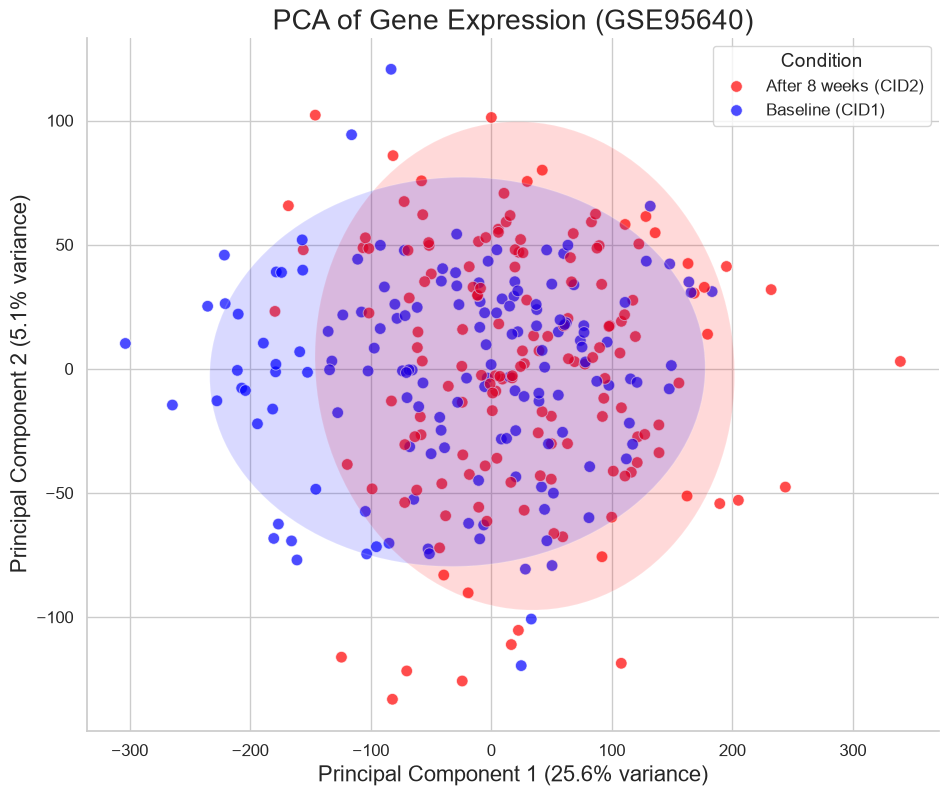

In [2]:
# --- Part 2: Exploratory Data Analysis (Adapted for GSE95640) ---

# --- Import necessary libraries for this section ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from sklearn.model_selection import train_test_split

# --- Global Plotting Style Setup ---
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.titlesize': 22,
})

from pathlib import Path
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _savefig(filename: str, dpi: int = 300):
    """Save current matplotlib figure into output/ with tight layout."""
    fp = OUT_DIR / filename
    plt.savefig(fp, dpi=dpi, bbox_inches="tight")
    print(f"[saved] {fp}")

print("--- Loading, Cleaning, and Splitting Data ---")
# Load the master dataframe created in Part 1.
raw_master_df = pd.read_csv('GSE95640_master_dataframe.csv', index_col=0, low_memory=False)

target_map = {
    'CID1 is for the baseline without LCD': 0,
    'CID2 is after 8 weeks of LCD': 1
}

raw_master_df_clean = raw_master_df.dropna(subset=['time']).copy()
y_temp = raw_master_df_clean['time'].map(target_map)

# Perform an 80/20 split
df_train_80, df_test_20 = train_test_split(
    raw_master_df_clean, 
    test_size=0.20, 
    stratify=y_temp, 
    random_state=42
)

# Save the split datasets separately
df_train_80.to_csv('GSE95640_train_80.csv')
df_test_20.to_csv('GSE95640_test_20.csv')
print(f"Data split successful!")
print(f"Train (80%) shape: {df_train_80.shape}")
print(f"Test (20%) shape: {df_test_20.shape}")

master_df = df_train_80.copy()

y = master_df['time'].map(target_map)

# Drop the target column to create the feature matrix X
X = master_df.drop(columns=['time'])

# Isolate gene expression data by defining and removing clinical/categorical columns
categorical_cols = [
    'tissue','gender','age'
]
cat_cols_in_df = [col for col in categorical_cols if col in X.columns]
print(f"Identified clinical columns to exclude from counts: {cat_cols_in_df}")

X_cont_raw = X.drop(columns=cat_cols_in_df)

# Log-transform the gene expression data
X_log_transformed = np.log1p(X_cont_raw)

# --- PCA on All Genes ---
print("--- Generating PCA Plot for All Genes (with Confidence Ellipses) ---")

# Scale the log-transformed data
scaler_global = StandardScaler()
X_log_scaled_global = scaler_global.fit_transform(X_log_transformed)

# Perform PCA
pca_global = PCA(n_components=2)
principal_components_global = pca_global.fit_transform(X_log_scaled_global)

# Create a DataFrame for plotting
pca_df_global = pd.DataFrame(data=principal_components_global, columns=['PC1', 'PC2'], index=X.index)

# 1. Define new plotting labels and palette
plot_labels = {0: 'Baseline (CID1)', 1: 'After 8 weeks (CID2)'}
palette = {'Baseline (CID1)': 'blue', 'After 8 weeks (CID2)': 'red'}

# 2. Map 'y' to the new text labels for the legend
pca_df_global['Condition'] = y.map(plot_labels).values
variance_explained_global = pca_global.explained_variance_ratio_

# --- Plotting Section with Ellipses ---
plt.figure(figsize=(11, 9))

# 3. Update 'hue' and 'palette'
ax = sns.scatterplot(
    x='PC1', y='PC2',
    hue='Condition',
    data=pca_df_global,
    palette=palette,
    s=70,
    alpha=0.7
)

# Add 95% confidence ellipses (Logic Unchanged)
for category in pca_df_global['Condition'].unique(): 
    subset = pca_df_global[pca_df_global['Condition'] == category]

    if subset.shape[0] < 2:
        continue

    cov = np.cov(subset['PC1'], subset['PC2'])
    center = subset[['PC1', 'PC2']].mean().values

    if not (np.any(np.isnan(cov)) or np.any(np.isinf(cov))):
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
            width, height = 2 * 2 * np.sqrt(eigenvalues)

            ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                              facecolor=palette.get(category, 'gray'), alpha=0.15)
            ax.add_patch(ellipse)
        except np.linalg.LinAlgError:
            print(f"Could not compute confidence ellipse for '{category}' group.")

# 4. Update titles and labels
ax.set_title("PCA of Gene Expression (GSE95640)")
ax.set_xlabel(f'Principal Component 1 ({variance_explained_global[0] * 100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({variance_explained_global[1] * 100:.1f}% variance)')
ax.legend(title='Condition')
sns.despine()
_savefig("pca_all_genes.png")
plt.show()

In [3]:
# --- Part 3: DESeq2 Differential Expression Analysis ---
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import numpy as np

print("--- Running DESeq2 Differential Expression Analysis ---")

samples_df = pd.DataFrame({'condition': y})

valid_indices = samples_df.dropna().index
samples_df_clean = samples_df.loc[valid_indices]
counts_df_clean = X_cont_raw.loc[valid_indices]
y_clean = y.loc[valid_indices]
X_log_transformed_clean = X_log_transformed.loc[valid_indices]


print(f"Running DESeq2 on {len(samples_df_clean)} samples.")
dds = DeseqDataSet(
    counts=counts_df_clean,
    metadata=samples_df_clean,
    design='~condition'
)

dds.deseq2()

normalized_counts_df = pd.DataFrame(
    dds.layers['normed_counts'],
    index=counts_df_clean.index,
    columns=counts_df_clean.columns
)

normalized_counts_df.to_csv('GSE95640_deseq2_normalized_counts.csv')
print("DESeq2 normalized counts saved to 'GSE95640_deseq2_normalized_counts.csv'")

stat_res = DeseqStats(dds, contrast=['condition', 1, 0])


stat_res.summary()
results_df = stat_res.results_df

results_df.to_csv('GSE95640_deseq2_statistical_results.csv')
print("DESeq2 statistical results saved to 'GSE95640_deseq2_statistical_results.csv'")

padj_thresh = 0.05
log2fc_thresh = 1.0

significant_genes_df = results_df[
    (results_df['padj'] < padj_thresh) &
    (abs(results_df['log2FoldChange']) > log2fc_thresh)
]

significant_genes = significant_genes_df.index.tolist()

print(f"\nDESeq2 analysis complete.")
print(f"Found {len(significant_genes)} significantly differentially expressed genes.")
print(f"(Using padj < {padj_thresh} and |log2FoldChange| > {log2fc_thresh})")

--- Running DESeq2 Differential Expression Analysis ---
Running DESeq2 on 305 samples.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.29 seconds.

Fitting dispersions...
... done in 1.55 seconds.

Fitting dispersion trend curve...
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 1.97 seconds.

Fitting LFCs...
... done in 1.46 seconds.

Calculating cook's distance...
... done in 0.44 seconds.

Replacing 350 outlier genes.

Fitting dispersions...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.08 seconds.



DESeq2 normalized counts saved to 'GSE95640_deseq2_normalized_counts.csv'


Running Wald tests...
... done in 1.21 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
DDX11L1           6.760515       -0.245918  0.112983 -2.176598  2.951061e-02   
WASH7P          347.253385        0.064930  0.057010  1.138931  2.547318e-01   
MIR6859-1        10.269327        0.204770  0.074804  2.737432  6.192083e-03   
MIR1302-2HG       0.551628       -0.420670  0.222674 -1.889178  5.886797e-02   
MIR1302-2         0.163857       -0.180689  0.480882 -0.375746  7.071059e-01   
...                    ...             ...       ...       ...           ...   
ND6           95358.299934       -0.170233  0.055784 -3.051664  2.275768e-03   
TRNE           7594.294479       -0.269503  0.053098 -5.075561  3.863552e-07   
CYTB         264874.990379       -0.245843  0.060051 -4.093928  4.241252e-05   
TRNT            700.700294       -0.361669  0.066863 -5.409110  6.333866e-08   
TRNP           2129.030064       -0.242642  0.063011 -3.850806  1

--- Visualizing results for 187 significant genes ---

--- Generating PCA Plot for Significant Genes ---
[saved] output\pca_significant_genes.png


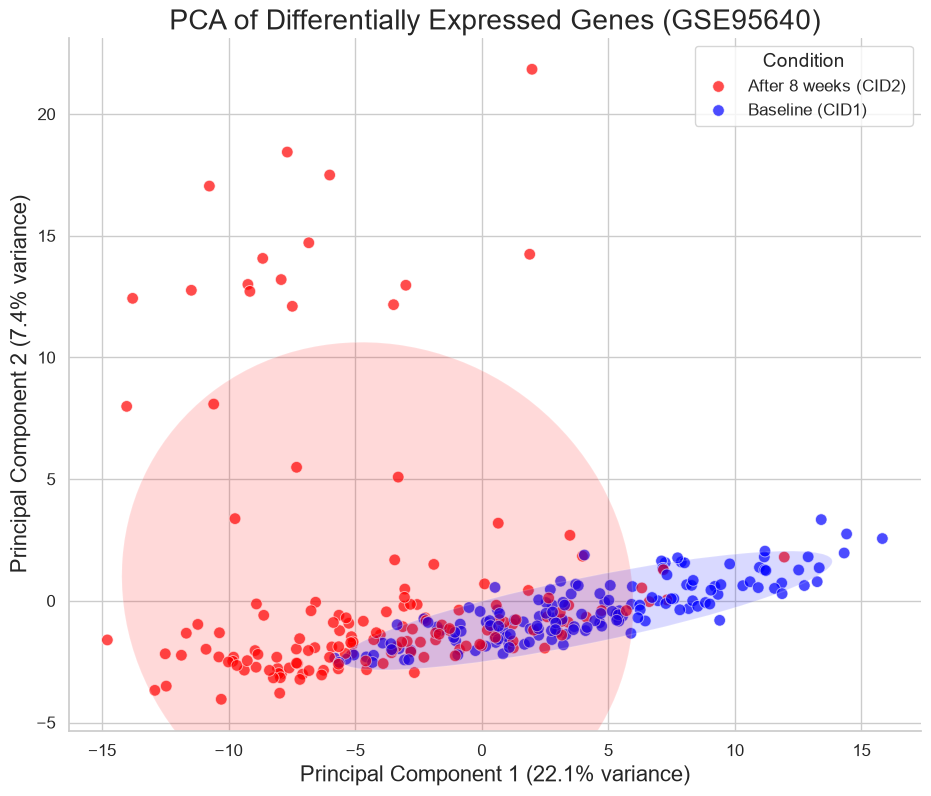

In [4]:
# --- Part 4: Visualization of Significant Genes ---
print(f"--- Visualizing results for {len(significant_genes)} significant genes ---")

# --- 1. PCA on Differentially Expressed Genes (DEGs) ---
print("\n--- Generating PCA Plot for Significant Genes ---")

X_significant_log = X_log_transformed_clean[significant_genes]

scaler_sig = StandardScaler()
X_significant_scaled = scaler_sig.fit_transform(X_significant_log)

# PCA
pca_sig = PCA(n_components=2)
principal_components_sig = pca_sig.fit_transform(X_significant_scaled)

pca_df_sig = pd.DataFrame(data=principal_components_sig, columns=['PC1', 'PC2'], index=X_significant_log.index)

pca_df_sig['Condition'] = y_clean.map(plot_labels).values
variance_explained_sig = pca_sig.explained_variance_ratio_

plt.figure(figsize=(11, 9))
ax_pca_sig = sns.scatterplot(
    x='PC1', y='PC2', hue='Condition', data=pca_df_sig,
    palette=palette, s=70, alpha=0.7
)

for category in pca_df_sig['Condition'].unique():
    subset = pca_df_sig[pca_df_sig['Condition'] == category]
    if subset.shape[0] > 1:
        cov = np.cov(subset['PC1'], subset['PC2'])
        center = subset[['PC1', 'PC2']].mean().values
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
            width, height = 2 * 2 * np.sqrt(eigenvalues)
            ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                              facecolor=palette.get(category, 'gray'), alpha=0.15)
            ax_pca_sig.add_patch(ellipse)
        except np.linalg.LinAlgError:
            pass 

ax_pca_sig.set_title("PCA of Differentially Expressed Genes (GSE95640)")
ax_pca_sig.set_xlabel(f'Principal Component 1 ({variance_explained_sig[0] * 100:.1f}% variance)')
ax_pca_sig.set_ylabel(f'Principal Component 2 ({variance_explained_sig[1] * 100:.1f}% variance)')
ax_pca_sig.legend(title='Condition')
sns.despine()
_savefig("pca_significant_genes.png")
plt.show()


--- Generating Centered Volcano Plot ---
[saved] output\volcano_plot.png


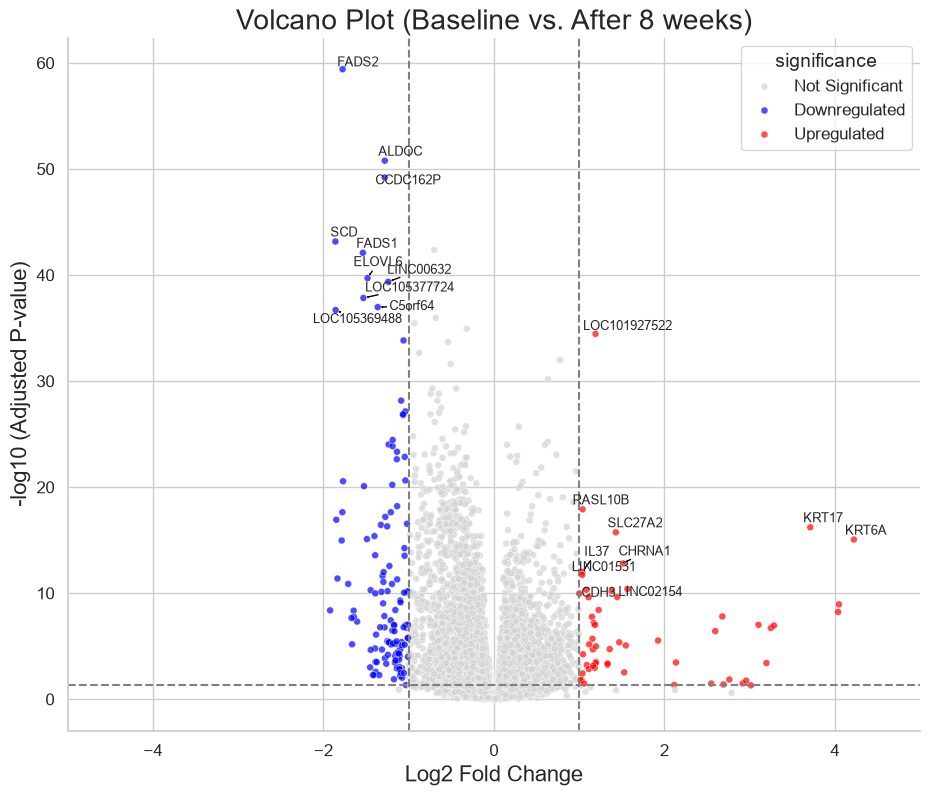

In [5]:
# --- 2. Volcano Plot ---

from adjustText import adjust_text

print("\n--- Generating Centered Volcano Plot ---")

results_df['-log10(padj)'] = -np.log10(results_df['padj'])
results_df.replace([np.inf, -np.inf], np.nan, inplace=True)
results_df.dropna(subset=['-log10(padj)'], inplace=True)

results_df['significance'] = 'Not Significant'
results_df.loc[(results_df['padj'] < padj_thresh) & (
            results_df['log2FoldChange'] > log2fc_thresh), 'significance'] = 'Upregulated'
results_df.loc[(results_df['padj'] < padj_thresh) & (
            results_df['log2FoldChange'] < -log2fc_thresh), 'significance'] = 'Downregulated'

top_upregulated = results_df[results_df['significance'] == 'Upregulated'].sort_values('padj').head(10)
top_downregulated = results_df[results_df['significance'] == 'Downregulated'].sort_values('padj').head(10)
genes_to_annotate = pd.concat([top_upregulated, top_downregulated])

plt.figure(figsize=(11, 9))
volcano_palette = {'Upregulated': 'red', 'Downregulated': 'blue', 'Not Significant': 'lightgrey'}
ax_volcano = sns.scatterplot(
    data=results_df, x='log2FoldChange', y='-log10(padj)',
    hue='significance', palette=volcano_palette,
    s=25, alpha=0.7, legend='full'
)

ax_volcano.axvline(x=log2fc_thresh, color='grey', linestyle='--')
ax_volcano.axvline(x=-log2fc_thresh, color='grey', linestyle='--')
ax_volcano.axhline(y=-np.log10(padj_thresh), color='grey', linestyle='--')

texts = []
for idx, row in genes_to_annotate.iterrows():
    texts.append(plt.text(row['log2FoldChange'], row['-log10(padj)'], idx, fontsize=9))

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

limit = np.ceil(results_df['log2FoldChange'].abs().max())
ax_volcano.set_xlim(-limit, limit)

ax_volcano.set_title('Volcano Plot (Baseline vs. After 8 weeks)')
ax_volcano.set_xlabel('Log2 Fold Change')
ax_volcano.set_ylabel('-log10 (Adjusted P-value)')
sns.despine()
_savefig("volcano_plot.png")
plt.show()


--- Generating Clustered Heatmap ---


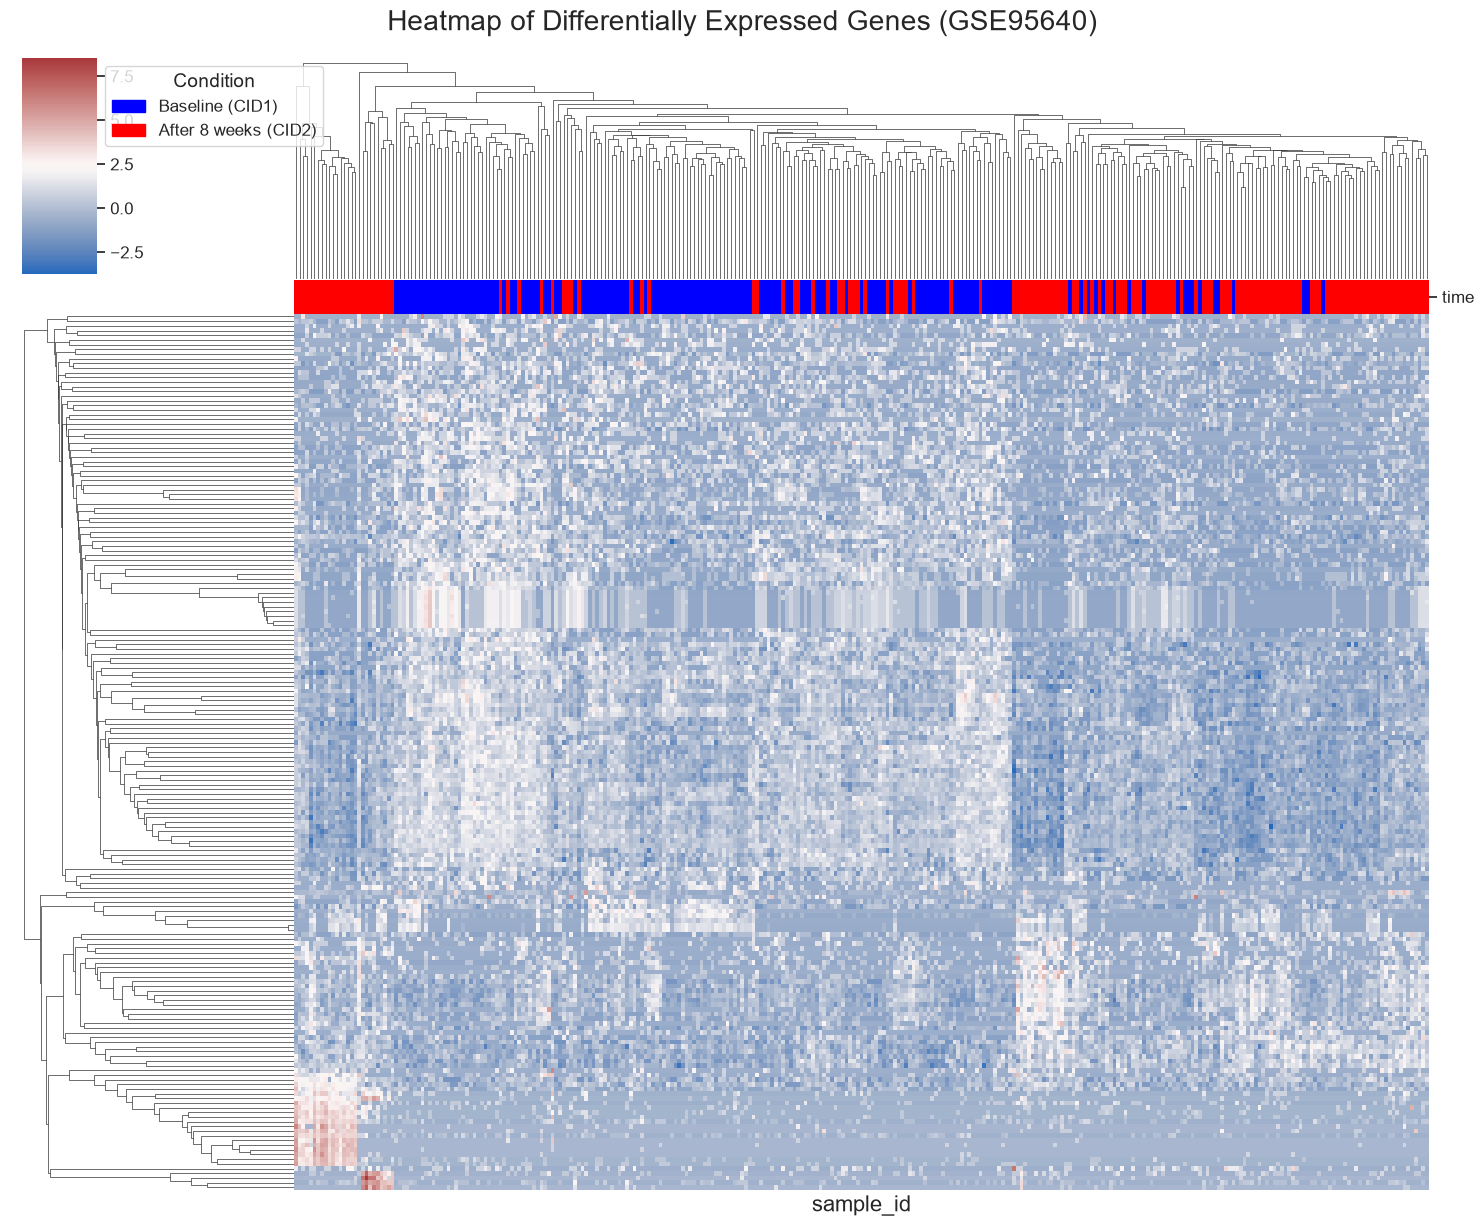

In [6]:
# --- 3. Clustered Heatmap ---
from scipy.stats import zscore

print("\n--- Generating Clustered Heatmap ---")

heatmap_data = X_log_transformed_clean[significant_genes]

heatmap_data_zscored = heatmap_data.apply(zscore, axis=0)

heatmap_data_zscored.fillna(0, inplace=True)
risk_categories = y_clean.map(plot_labels)
col_colors = risk_categories.map(palette)

g = sns.clustermap(
    heatmap_data_zscored.T,
    cmap='vlag', 
    col_colors=col_colors,
    figsize=(15, 12),
    yticklabels=False,
    xticklabels=False 
)

g.fig.suptitle('Heatmap of Differentially Expressed Genes (GSE95640)', fontsize=20, y=1.02)
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in palette.values()]
plt.legend(handles, palette.keys(), title='Condition', bbox_to_anchor=(1, 1), loc='upper left')
g.fig.savefig(OUT_DIR / "heatmap_deg_clustermap.png", dpi=300, bbox_inches="tight")
plt.show()